In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU

In [6]:
from tensorflow.keras.datasets import imdb

vocab_size = 10000  

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [7]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

In [8]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post')

In [9]:
rnn_model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

c:\Users\Karan singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5176 - loss: 0.6913 - val_accuracy: 0.5438 - val_loss: 0.6830
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5929 - loss: 0.6593 - val_accuracy: 0.5650 - val_loss: 0.6603
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6252 - loss: 0.6155 - val_accuracy: 0.5778 - val_loss: 0.6570
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6641 - loss: 0.5828 - val_accuracy: 0.5350 - val_loss: 0.7124
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6827 - loss: 0.4878 - val_accuracy: 0.5816 - val_loss: 0.7062


In [10]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 78ms/step - accuracy: 0.5719 - loss: 0.6610 - val_accuracy: 0.5930 - val_loss: 0.6309
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.6895 - loss: 0.5620 - val_accuracy: 0.6364 - val_loss: 0.5943
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7532 - loss: 0.4974 - val_accuracy: 0.5732 - val_loss: 0.6558
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.7769 - loss: 0.4706 - val_accuracy: 0.7984 - val_loss: 0.4825
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8668 - loss: 0.3307 - val_accuracy: 0.8496 - val_loss: 0.3875


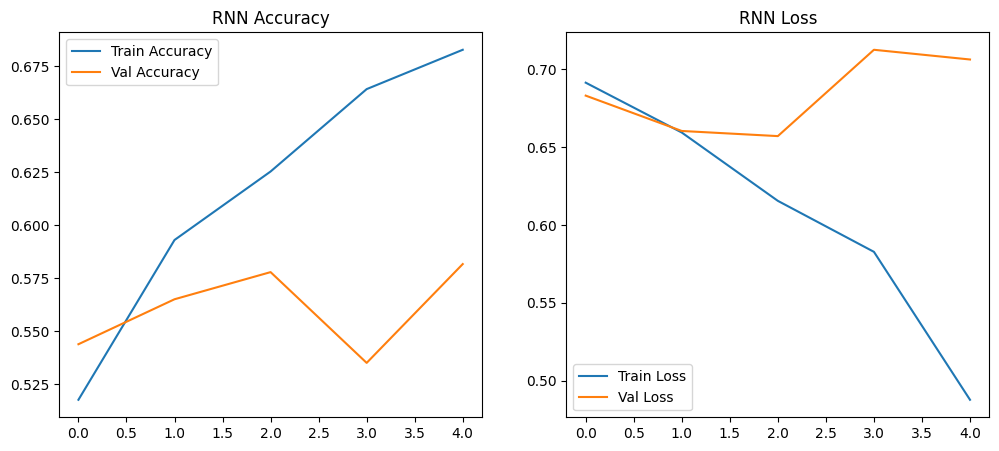

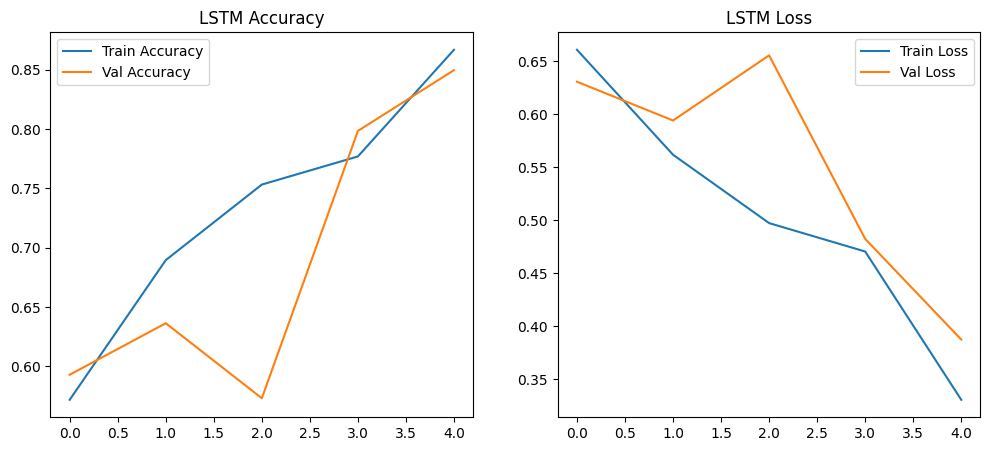

In [11]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

plot_history(rnn_history, "RNN")
plot_history(lstm_history, "LSTM")

In [12]:
# RNN Predictions
rnn_preds = (rnn_model.predict(X_test) > 0.5).astype("int32")

print("RNN Classification Report:")
print(classification_report(y_test, rnn_preds))

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
RNN Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.32      0.43     12500
           1       0.55      0.84      0.67     12500

    accuracy                           0.58     25000
   macro avg       0.61      0.58      0.55     25000
weighted avg       0.61      0.58      0.55     25000



In [13]:
# LSTM Predictions
lstm_preds = (lstm_model.predict(X_test) > 0.5).astype("int32")

print("LSTM Classification Report:")
print(classification_report(y_test, lstm_preds))

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step
LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85     12500
           1       0.85      0.84      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [14]:
max_length = 300 

In [15]:
Embedding(vocab_size, 32)  

<Embedding name=embedding_2, built=False>